In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('economic_index.csv')

In [4]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [5]:
df.drop(labels=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [6]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [7]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

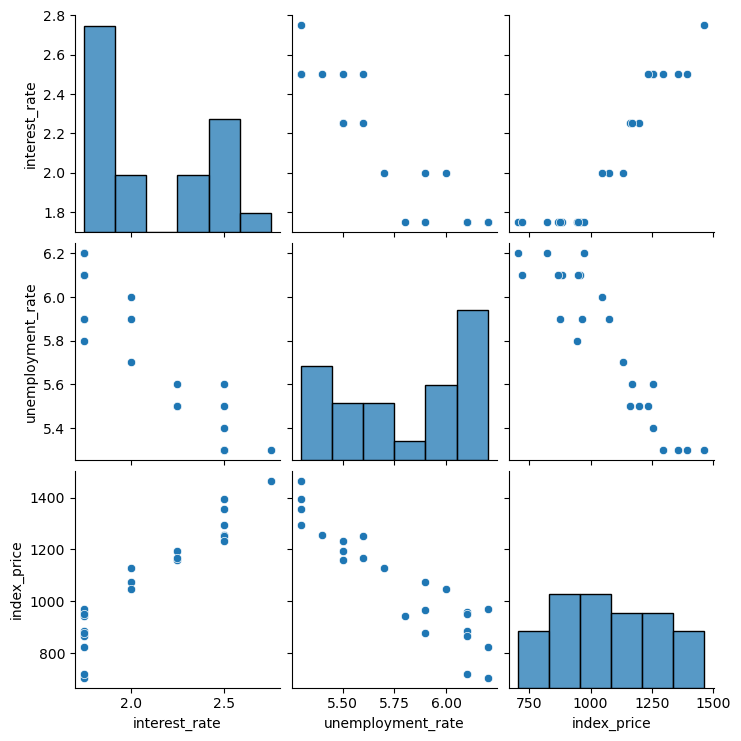

In [8]:
sns.pairplot(df)

In [9]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


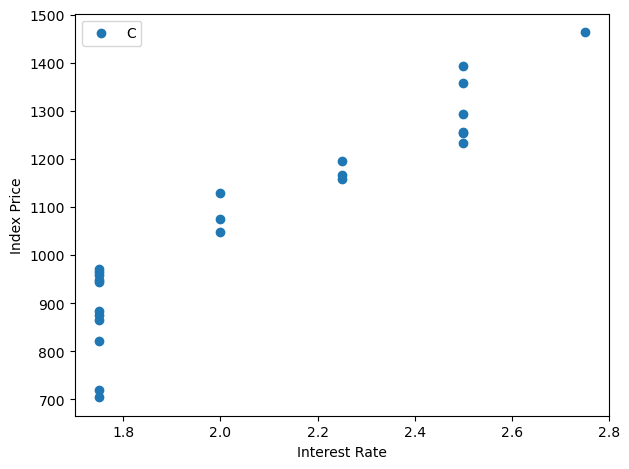

In [10]:
plt.scatter(df['interest_rate'],df['index_price'])
plt.xlabel('Interest Rate')
plt.ylabel('Index Price')
plt.legend('Correlation between interest rate and index price')
plt.tight_layout()

Shaded region accross the line tells that you can hyperparameter tune that line for best results


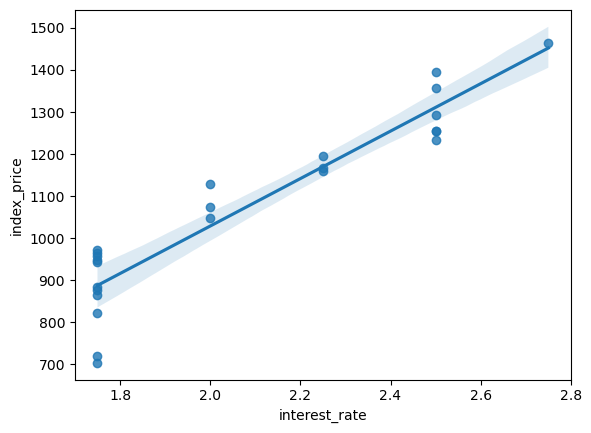

In [11]:
sns.regplot(x=df['interest_rate'], y=df['index_price'])
print("Shaded region accross the line tells that you can hyperparameter tune that line for best results")

In [12]:
x = df.drop('index_price',axis=1)

In [13]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [14]:
y = df['index_price']

In [15]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
regression = LinearRegression()

In [23]:
regression.fit(x_train,y_train)

LinearRegression()

### In Cross validation - dataset is divided into k folds , then k-1 folds are used to train the data and kth fold to test the data , similarly we inc the test data

In [25]:
from sklearn.model_selection import cross_val_score

In [26]:
val_score = cross_val_score(regression,x_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [27]:
print(f"The mean of cross validation score is: {np.mean(val_score)}")

The mean of cross validation score is: -5914.828180162388


In [28]:
y_pred = regression.predict(x_test)

In [29]:
from sklearn.metrics import mean_absolute_error , mean_squared_error
from sklearn.metrics import r2_score
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(f"MSE: {mse}\nMAE:{mae}\nRMSE:{rmse}")
score = r2_score(y_test,y_pred)
adj_r2_score = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)
print(f'R2 score is : {score}')
print(f'Adjusted R2 score is : {adj_r2_score}')

MSE: 5793.762887712583
MAE:59.93578152323558
RMSE:76.11677139574815
R2 score is : 0.8278978091457141
Adjusted R2 score is : 0.7131630152428567


### Plotting y test and y pred in order to check whether model is good or not

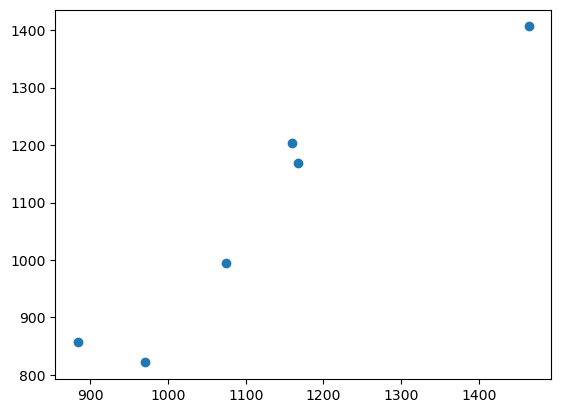

In [31]:
plt.scatter(y_test,y_pred)

In [32]:
residuals = y_test - y_pred
residuals

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64

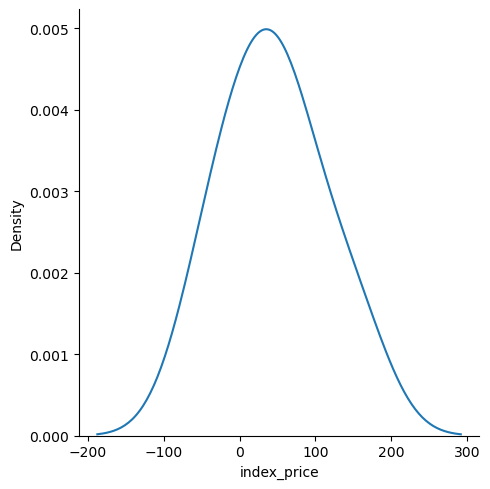

In [33]:
sns.displot(residuals,kind='kde')

If it does not follow any pattern or the data is uniformly distributed then it is good or model is working well


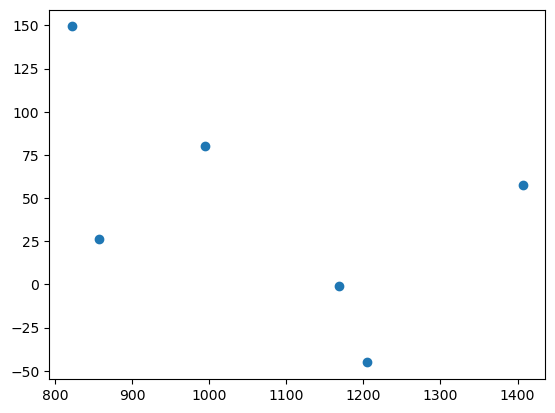

In [34]:
plt.scatter(y_pred,residuals)
print('If it does not follow any pattern or the data is uniformly distributed then it is good or model is working well')

In [35]:
import statsmodels.api as sm
model = sm.OLS(y_train,x_train).fit()
predictions = model.predict(x_test)
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Wed, 28 Jan 2026   Prob (F-statistic):                       0.754
Time:                        09:23:53   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

D:\Anaconda\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


In [36]:
print(regression.coef_)

[  88.27275507 -116.25716066]
